Understand the power of the analysis

Significance if the depth was smaller

In [1]:
#import Pkg; Pkg.activate(".");
using RCall
using Random
using DataFrames, DataFramesMeta
using Revise
using CSV
using StatsBase
using Statistics
using Arrow
using HypothesisTests
using MultipleTesting
using PoissonRandom

LoadError: ArgumentError: Package PoissonRandom not found in current path.
- Run `import Pkg; Pkg.add("PoissonRandom")` to install the PoissonRandom package.

In [13]:
base_name = "multiple_runs14"
run_date = "20250204"
figure_export_dir = "./exp/$(base_name)/figs/R02_Window_Stat"
mkpath(figure_export_dir)
data_export_dir = "./exp/$(base_name)/data/ins_del_analysis"
base_dir = "exp/$(base_name)"
misc_dir = "../misc"
tmp_dir =joinpath(base_dir, "tmp", "R02_Window_Stat")
mkpath(tmp_dir)
base_dir_event_classification = joinpath(base_dir, "export/classify_IS_events")
file_prefix = "$(run_date)_"

"20250204_"

In [5]:
is_in_mds42_df_prevgen = CSV.read(joinpath(base_dir, "export", "classify_IS_events_MDS", "is_in_mds42.df.prevgen.csv"), DataFrame)
first(is_in_mds42_df_prevgen, 2)

Row,pos_id,IS_strand,flank,pos,genome,cluster_id,insert_id,flankMatchDir,position_status,sv,Line,Parent,Subline,Gen_id,Gen,matched_row.prev,matched_row.facs
,Int64,Bool,String1,Int64,String7,Int64,Int64,Bool,String15,String31,String7,Int64,Int64,Int64,String7,String7,String7
1,0,false,r,476936,Query,2,1,true,new,simple_insertion,L01-1,1,1,1,FACS,NA,1
2,0,false,f,476923,Query,2,1,false,new,simple_insertion,L01-1,1,1,1,FACS,NA,1


In [6]:

# Sliding window function
function sliding_window_analysis(pos::Vector{Int}, genome_size, bin_size::Int = 100000, step_size::Int = 1000, 
                                alpha::Float64 = 0.05, binom_test::Bool = true)

    mutations = DataFrame(position=pos)

    genome_start = 1
    genome_end = genome_size

    # Handle circular genome
    mutations_extended = vcat(mutations, 
                              DataFrame(position=mutations.position .+ genome_end), 
                              DataFrame(position=mutations.position .- genome_end))
    #print(mutations_extended[1 .< mutations_extended.position .< 1e5, :])

    # Define sliding windows
    starts = collect(genome_start:step_size:genome_size)
    ends = starts .+ bin_size .- 1
	windows = DataFrame("start"=>starts, "end"=>ends)

    # Count mutations in each window
    windows.mutation_count = [sum((mutations_extended.position .>= s) .& (mutations_extended.position .<= e)) 
                              for (s, e) in zip(windows.start, windows.end)]

    # Mutations per bp
    windows.mutations_per_bp = windows.mutation_count ./ bin_size

    mutation_rate = size(mutations, 1) / (genome_size - genome_start + 1)

    if binom_test
        # Perform binomial tests
        windows.p_value = [pvalue(BinomialTest(n, bin_size, mutation_rate)) for n in windows.mutation_count]
        windows.adjusted_p_value = adjust(windows.p_value, BenjaminiHochberg())
        windows.significant = windows.adjusted_p_value .< alpha
        windows.test_side = ifelse.(windows.mutation_count .> bin_size * mutation_rate, "high", "low")

        # Print top significant results
        #println(first(sort(windows[windows.significant, :], :adjusted_p_value), min(5, sum(windows.significant))))
    end

    return (windows, mutation_rate)
end

sliding_window_analysis (generic function with 5 methods)

In [7]:

df = is_in_mds42_df_prevgen

# Filter and mutate
tmp_df = df[df.Gen .!= "FACS", :]
tmp_df = tmp_df["NA".==(tmp_df[:,Symbol("matched_row.prev")]),:]
tmp_df.Type = ifelse.(tmp_df.sv .== "simple_insertion", "Simple", "Complex")

genome_size = 3980425
tmp_df_g = DataFramesMeta.combine(groupby(tmp_df, [:Line, :Gen, :insert_id]),
    :pos => mean => :pos,
    :sv => (x -> all(x .== "simple_insertion") ? "simple_insertion" : "unknown") => :sv
)
windows_res = sliding_window_analysis(round.(Int64, tmp_df_g.pos), genome_size);
print(windows_res[2])
windows_res[1] |> x -> first(x, 2)

0.00023138232726404844

Row,start,end,mutation_count,mutations_per_bp,p_value,adjusted_p_value,significant,test_side
,Int64,Int64,Int64,Float64,Float64,Float64,Bool,String
1,1,100000,14,0.00014,0.0584491,0.154027,false,low
2,1001,101000,14,0.00014,0.0584491,0.154027,false,low


In [8]:
windows_total_res_df = windows_res[1]
sort(windows_total_res_df, :mutation_count, rev=true) |> x -> first(x, 5)

Row,start,end,mutation_count,mutations_per_bp,p_value,adjusted_p_value,significant,test_side
,Int64,Int64,Int64,Float64,Float64,Float64,Bool,String
1,2066001,2166000,56,0.00056,1.05536e-8,1.30376e-5,true,high
2,2064001,2164000,55,0.00055,2.5851e-8,1.30376e-5,true,high
3,2065001,2165000,55,0.00055,2.5851e-8,1.30376e-5,true,high
4,2078001,2178000,55,0.00055,2.5851e-8,1.30376e-5,true,high
5,2063001,2163000,54,0.00054,6.22244e-8,1.30376e-5,true,high


In [9]:
windows_total_res_df[windows_total_res_df.significant, :] |> size 

(1058, 8)

In [10]:
windows_res = sliding_window_analysis(
	round.(Int64, tmp_df_g[tmp_df_g.sv .== "simple_insertion", :pos]),
		genome_size);
println(windows_res[2])
windows_simple_res_df = windows_res[1]
windows_simple_res_df[windows_simple_res_df.significant, :] |> size |> println
windows_simple_res_df |> x -> first(x, 5)

9.119629185325688e-5
(0, 8)


Row,start,end,mutation_count,mutations_per_bp,p_value,adjusted_p_value,significant,test_side
,Int64,Int64,Int64,Float64,Float64,Float64,Bool,String
1,1,100000,11,0.00011,0.616566,0.963591,false,high
2,1001,101000,11,0.00011,0.616566,0.963591,false,high
3,2001,102000,11,0.00011,0.616566,0.963591,false,high
4,3001,103000,11,0.00011,0.616566,0.963591,false,high
5,4001,104000,11,0.00011,0.616566,0.963591,false,high


## Statistics 
simulate multiple runs to test significance

In [117]:
rates = 10 .^ collect(-1:0.1:1)
n_ins = 10 .* 10 .^ collect(-0.3:0.1:2)
n_ins = round.(Int64, n_ins)
n_iter = 100
seed = 1
genome_size = 3980425
window_size = 100000
rng = Xoshiro(seed)

res_df = DataFrame(rate=Float64[], n_ins=Int[], min_p=Float64[], min_adj_p=Float64[],
			sig_cnt = Int[])

for rate in rates
	for n_ins_ in n_ins
		p_vals = Float64[]
		adj_p_vals = Float64[]
		sig_cnts = Int[]
		for i in 1:n_iter
			#n_ins_window = pois_rand(rng, n_ins_ * window_size / genome_size * rate)
			n_ins_window = pois_rand(rng, n_ins_ * window_size / (genome_size - (1-rate) * window_size) * rate)
			ins_pos = sort(rand(rng, 1:window_size, n_ins_window))
			n_ins_else = n_ins_ - n_ins_window
			ins_pos = vcat(ins_pos, sort(rand(rng, (window_size+1):genome_size, n_ins_else)))
			windows_res = sliding_window_analysis(ins_pos, genome_size)
			push!(p_vals, minimum(windows_res[1].p_value))
			push!(adj_p_vals, minimum(windows_res[1].adjusted_p_value))
			push!(sig_cnts, sum(windows_res[1].significant))
		end
		res_df = vcat(
			res_df,
			DataFrame(rate=rate, n_ins=n_ins_, min_p=p_vals, min_adj_p=adj_p_vals,
				sig_cnt=sig_cnts)
		)
		mean_sig_cnt = mean(sig_cnts)
		println("rate: $(rate), n_ins: $(n_ins_), sig_cnts: $(mean_sig_cnt)")
	end
end

res_df |> x -> first(x, 5)

rate: 0.1, n_ins: 5, sig_cnts: 0.0
rate: 0.1, n_ins: 6, sig_cnts: 0.0
rate: 0.1, n_ins: 8, sig_cnts: 0.0
rate: 0.1, n_ins: 10, sig_cnts: 0.23
rate: 0.1, n_ins: 13, sig_cnts: 0.74
rate: 0.1, n_ins: 16, sig_cnts: 0.0
rate: 0.1, n_ins: 20, sig_cnts: 0.8
rate: 0.1, n_ins: 25, sig_cnts: 1.39
rate: 0.1, n_ins: 32, sig_cnts: 0.31
rate: 0.1, n_ins: 40, sig_cnts: 0.46
rate: 0.1, n_ins: 50, sig_cnts: 0.0
rate: 0.1, n_ins: 63, sig_cnts: 0.0
rate: 0.1, n_ins: 79, sig_cnts: 0.0
rate: 0.1, n_ins: 100, sig_cnts: 0.75
rate: 0.1, n_ins: 126, sig_cnts: 0.73
rate: 0.1, n_ins: 158, sig_cnts: 0.17
rate: 0.1, n_ins: 200, sig_cnts: 0.0
rate: 0.1, n_ins: 251, sig_cnts: 0.25
rate: 0.1, n_ins: 316, sig_cnts: 3.74
rate: 0.1, n_ins: 398, sig_cnts: 7.65
rate: 0.1, n_ins: 501, sig_cnts: 19.36
rate: 0.1, n_ins: 631, sig_cnts: 37.76
rate: 0.1, n_ins: 794, sig_cnts: 53.66
rate: 0.1, n_ins: 1000, sig_cnts: 71.43
rate: 0.12589254117941673, n_ins: 5, sig_cnts: 0.72
rate: 0.12589254117941673, n_ins: 6, sig_cnts: 0.0
rate:

Row,rate,n_ins,min_p,min_adj_p,sig_cnt
,Float64,Int64,Float64,Float64,Int64
1,0.1,5,0.236091,1.0,0
2,0.1,5,0.236091,1.0,0
3,0.1,5,0.0145178,1.0,0
4,0.1,5,0.236091,1.0,0
5,0.1,5,0.0145178,0.621454,0


In [132]:
# save
window_test_grid_search_res_dir = joinpath(tmp_dir, "window_test_grid_search.csv")
CSV.write(window_test_grid_search_res_dir, res_df)

"exp/multiple_runs14/tmp/R02_Window_Stat/window_test_grid_search.csv"

In [14]:
window_test_grid_search_res_dir = joinpath(tmp_dir, "window_test_grid_search.csv")
@rput window_test_grid_search_res_dir
@rput figure_export_dir
R"""
Sys.setlocale("LC_COLLATE","C") # order by dictionary order
library(tidyverse)
library(cowplot)
library(latex2exp)
library(stats)
library(scales)
library(lemon)
library(gghalves)
library(ggbeeswarm)
library(ggpointdensity)
library(viridis)
library(forcats)
library(MASS)
library(sfsmisc)
library(ggnewscale)
library(ggrastr)
library(car)
library(arrow)
library(fitdistrplus)
library(performance)
cbp <- c("#999999", "#E69F00", "#56B4E9", "#009E73", 
                       "#F0E442", "#0072B2", "#D55E00", "#CC79A7")
select <- dplyr::select
filter <- dplyr::filter
lag <- dplyr::lag
""";

In [12]:
R"""
grid_df <- read_csv(window_test_grid_search_res_dir)
grid_df %>% head
"""

┌ Warning: RCall.jl: Rows: 50400 Columns: 6
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ dbl (6): rate, n_ins, min_p, min_adj_p, sig_cnt, n_ins_raw
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 6 × 6
   rate n_ins  min_p min_adj_p sig_cnt n_ins_raw
  <dbl> <dbl>  <dbl>     <dbl>   <dbl>     <dbl>
1   0.1     5 0.236      1           0      5.01
2   0.1     5 0.236      1           0      5.01
3   0.1     5 0.0145     1           0      5.01
4   0.1     5 0.236      1           0      5.01
5   0.1     5 0.0145     0.621       0      5.01
6   0.1     5 0.0145     1           0      5.01


┌ Warning: RCall.jl: `summarise()` has grouped output by 'rate'. You can override using the
│ `.groups` argument.
└ @ RCall ~/.julia/packages/RCall/0ggIQ/src/io.jl:172


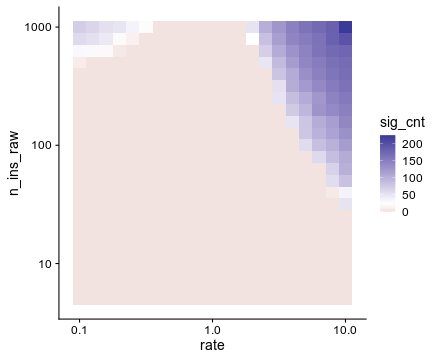

RObject{VecSxp}


In [135]:
R"""
grid_df %>%
	group_by(rate, n_ins_raw) %>%
	summarise(sig_cnt = median(sig_cnt)) %>%
	ggplot(aes(x = rate, y = n_ins_raw, fill = sig_cnt)) +
	scale_x_log10() +scale_y_log10() + 
	scale_fill_gradient2(midpoint = 25) +
	geom_tile() +
	theme_half_open()
"""

┌ Warning: RCall.jl: `summarise()` has grouped output by 'rate', 'n_ins'. You can override using the
│ `.groups` argument.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


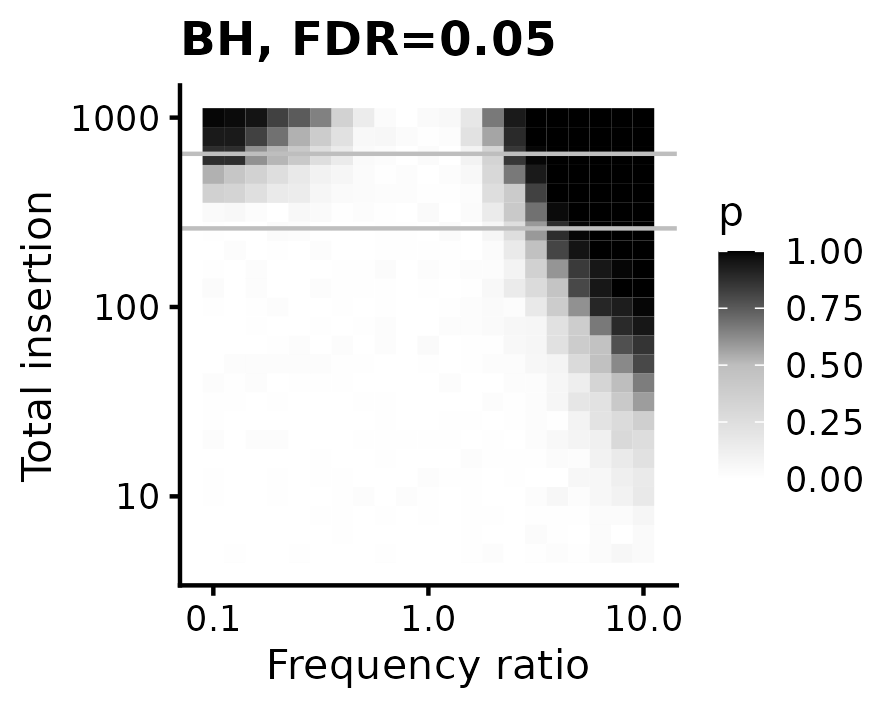

In [46]:
figure_name = file_prefix * "bh_simulation_fdr_0.05"
@rput figure_name
R"""
p <- grid_df %>%
	group_by(rate, n_ins, n_ins_raw) %>%
	summarise(sig_cnt_ = median(sig_cnt), sig_prob = sum(sig_cnt > 0) / n()) %>%
	ggplot(aes(x = rate, y = n_ins_raw, fill = sig_prob)) +
	scale_fill_gradient2(midpoint = 0.5, low = "white", high = "black", mid = "grey") +
	labs(x = "Frequency ratio", y = "Total insertion", fill = "p", title = "BH, FDR=0.05") + 
	geom_tile() +
	scale_x_log10() +scale_y_log10() + 
	geom_hline(yintercept=902, color = "grey") +
	geom_hline(yintercept=366, color = "grey") +
	theme_half_open(10)

p.bh.sim.fdr005 <- p

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=75, height=60, units="mm", dpi=300)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=75, height=60, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

┌ Warning: RCall.jl: `summarise()` has grouped output by 'rate', 'n_ins'. You can override using the
│ `.groups` argument.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


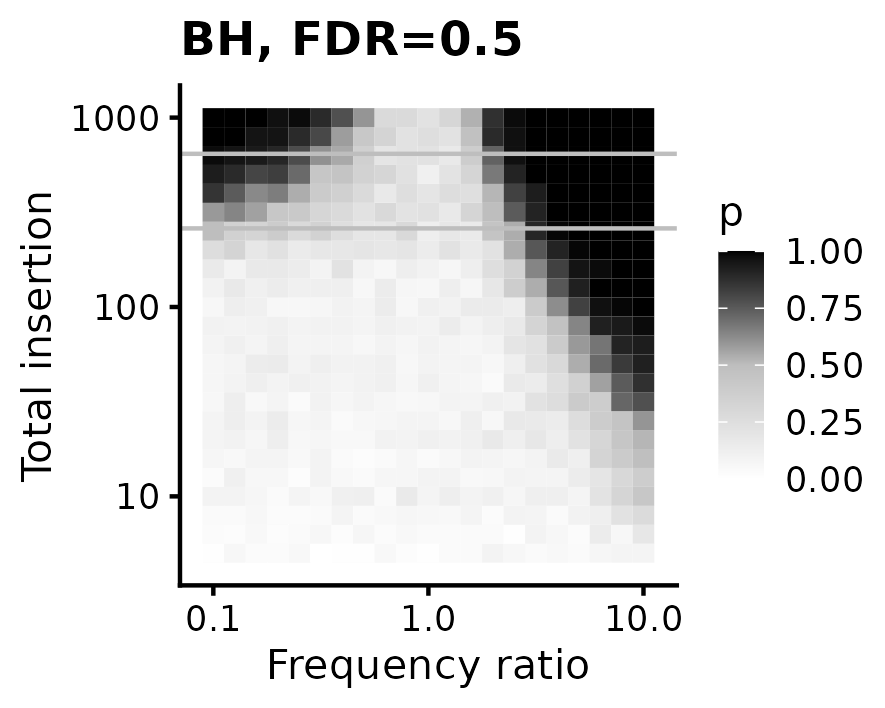

In [30]:
ENV["LINES"], ENV["COLUMNS"] = 30, 80
figure_name = file_prefix * "bh_simulation_fdr_0.5"
@rput figure_name
R"""
p <- grid_df %>%
	group_by(rate, n_ins, n_ins_raw) %>%
	summarise(sig_cnt_ = median(sig_cnt), sig_prob = sum(min_adj_p < 0.5) / n()) %>%
	ggplot(aes(x = rate, y = n_ins_raw, fill = sig_prob)) +
	scale_fill_gradient2(midpoint = 0.5, low = "white", high = "black", mid = "grey") +
	labs(x = "Frequency ratio", y = "Total insertion", fill = "p", title = "BH, FDR=0.5") + 
	geom_tile() +
	scale_x_log10() +scale_y_log10() + 
	geom_hline(yintercept=902, color = "grey") +
	geom_hline(yintercept=366, color = "grey") +
	theme_half_open(10)


ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=75, height=60, units="mm", dpi=300)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=75, height=60, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

## Random subsample total data

In [33]:
first(tmp_df_g ,2)

Row,Line,Gen,insert_id,pos,sv
,String7,String7,Int64,Float64,String
1,L01-1,MA08,2,549440.0,unknown
2,L01-1,MA08,3,554375.0,unknown


In [35]:
n_ins = 366 # simple insertion 20250204
n_iter = 1000
seed = 1
genome_size = 3980425
window_size = 100000
rng = Xoshiro(seed)

window_df_lst = []
for i in 1:n_iter
	ins_pos = sample(rng, tmp_df_g.pos, n_ins, replace=true)
	ins_pos = round.(Int64, ins_pos)
	sort!(ins_pos)
	windows_res = sliding_window_analysis(ins_pos, genome_size)
	windows_res_ = windows_res[1]
	windows_res_[!,:iter] .= i
	windows_res_[!,:n_ins] .= n_ins
	windows_df_lst = push!(window_df_lst, windows_res_)
end

windows_sub_df = vcat(window_df_lst...)

windows_sub_df |> x -> first(x, 5)

Row,start,end,mutation_count,mutations_per_bp,p_value,adjusted_p_value,significant,test_side,iter,n_ins
,Int64,Int64,Int64,Float64,Float64,Float64,Bool,String,Int64,Int64
1,1,100000,1,1.0e-5,0.0219318,0.136422,false,low,1,260
2,1001,101000,1,1.0e-5,0.0219318,0.136422,false,low,1,260
3,2001,102000,1,1.0e-5,0.0219318,0.136422,false,low,1,260
4,3001,103000,1,1.0e-5,0.0219318,0.136422,false,low,1,260
5,4001,104000,1,1.0e-5,0.0219318,0.136422,false,low,1,260


In [37]:
# number of significant per iteration
windows_sub_df_stat = DataFramesMeta.combine(groupby(windows_sub_df, [:iter]),
	:significant => sum => :sig_cnt)
windows_sub_df_stat |> x -> first(x, 5)

Row,iter,sig_cnt
,Int64,Int64
1,1,253
2,2,318
3,3,9
4,4,346
5,5,40


[1] 404


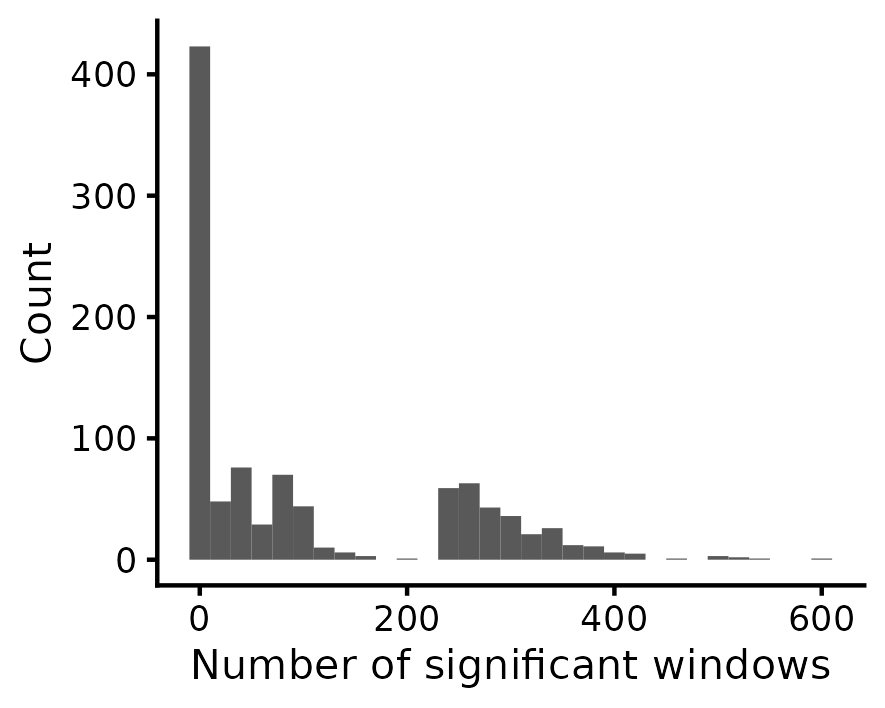

In [47]:
@rput windows_sub_df_stat
figure_name = file_prefix * "subsample_simulation_fdr_0.05_hist"
@rput figure_name
R"""
windows_sub_df_stat %>% filter(sig_cnt == 0) %>% nrow() %>% print
p <- windows_sub_df_stat %>%
	ggplot(aes(x = sig_cnt)) +
	geom_histogram(binwidth = 20) +
	theme_half_open(10) +
	labs(x = "Number of significant windows", y = "Count")

p.sub.sim.fdr005.hist <- p

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=75, height=60, units="mm", dpi=300)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=75, height=50, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))